#**Nanoparticle Sintering Dataset Preparation for Cu-Cu Sintering Study with ML** <p align=justify>This notebook processes LAMMPS trajectory files to compute sintering metrics using SciPy and NumPy instead of OVITO modifiers, and prepares a machine learning-ready dataset.
Features Computed
 1. **Static Features**: Particle sizes, temperature, initial configuration
 2. **Dynamic Features**: Time-dependent properties (neck radius, shrinkage, etc.)
 3. **Target Variables**: Neck growth, shrinkage ratio, density, and more

#**Package Installation and Libraries**


In [ ]:
!pip install ovito

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.4/114.4 MB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 563.4/563.4 kB 24.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 170.7/170.7 MB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 MB 10.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 273.1/273.1 kB 22.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.1/5.1 MB 79.7 MB/s eta 0:00:00


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from tqdm import tqdm
from scipy.spatial import ConvexHull, distance_matrix, KDTree
from sklearn.cluster import KMeans
from ovito.io import import_file
from ovito.modifiers import CoordinationAnalysisModifier, CommonNeighborAnalysisModifier
import re
import warnings
warnings.filterwarnings('ignore', category=UserWarning)  # Suppress convex hull warnings

In [ ]:
# Load the Google drive in notebook and mount it.
from google.colab import drive   # comment if already done this.
drive.mount('/content/drive/')   # comment if already done this.

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


In [ ]:
# Update your input file path (IFP)
%ls #%cd /content/drive/Othercomputers/MyLaptop/TERM2/CDS524_ML4B/Assign_Grp/LAMMPS_TRAJ_FILEs/
IFP = '/content/drive/Othercomputers/MyLaptop/TERM2/CDS524_ML4B/Assign_Grp/LAMMPS_TRAJ_FILEs/' #./LAMMPS_TRAJ_FILEs/'

drive/  sample_data/


#**Configuration**


In [ ]:
# Configuration
TRAJECTORY_DIR = IFP                           # Directory with LAMMPS trajectory files, Modify these paths according to your system setup
OUTPUT_FILE = "sintering_dataset.parquet"      # Output dataset file
A0 = 3.615                                     # Cu lattice constant in Ã…
DELTA = 2 * A0                                 # Slab thickness for neck analysis
ATOMIC_MASS_CU = 63.546 / 6.022e23             # Grams per atom (g/atom)
BULK_DENSITY_CU = 8.96                         # g/cmÂ³
NEAREST_NEIGHBOR_CUTOFF = 3.5  # Å for coordination number

#**Helper Functions**

In [ ]:
def parse_filename(filename):
    """Extract simulation parameters from filename"""
    parts = filename.split('_')

    if not parts:
        return None

    r1 = float(parts[0][1:]) * A0  # Convert from a0 units to Ã…
    r2 = float(parts[1][1:]) * A0
    temp = float(parts[2][1:].split('.')[0])

    return {
        'sim_id': filename.split(".")[0], #.replace('.lammpstrj', ''),
        'r1': r1,
        'r2': r2,
        'T': temp,
        'particle_type': "same" if r1 == r2 else "diff",
        'size_ratio': max(r1, r2) / min(r1, r2)
    }

def compute_com(positions):
    """Compute center of mass of a set of positions"""
    return np.mean(positions, axis=0)

def compute_neck_radius(positions, com1, com2):
    """Calculate neck radius using convex hull projection method"""
    midpoint = (com1 + com2) / 2
    axis = com2 - com1
    axis_norm = np.linalg.norm(axis)

    if axis_norm < 1e-5:  # Particles merged
        return 0.0

    normal = axis / axis_norm

    # Create orthogonal basis vectors
    if abs(normal[0]) < 0.9:
        u = np.array([1.0, 0.0, 0.0])
    else:
        u = np.array([0.0, 1.0, 0.0])
    u -= np.dot(u, normal) * normal
    u /= np.linalg.norm(u)
    v = np.cross(normal, u)

    # Project atoms onto the plane
    vectors = positions - midpoint
    proj_vectors = vectors - np.outer(np.dot(vectors, normal), normal)
    u_coords = np.dot(proj_vectors, u)
    v_coords = np.dot(proj_vectors, v)
    points_2d = np.column_stack([u_coords, v_coords])

    # Compute convex hull area
    if len(points_2d) < 3:
        return 0.0

    try:
        hull = ConvexHull(points_2d)
        area = hull.volume  # For 2D, volume is area
        return np.sqrt(area / np.pi)
    except:
        return 0.0

def compute_gyration_radius(positions):
    """Compute radius of gyration for a set of positions"""
    com = compute_com(positions)
    squared_dist = np.sum((positions - com)**2, axis=1)
    return np.sqrt(np.mean(squared_dist))

def compute_density(positions):
    """Compute density via convex hull volume"""
    if len(positions) < 4:
        return 0.0

    try:
        hull = ConvexHull(positions)
        volume = hull.volume  # Volume in Å³
        total_mass = len(positions) * ATOMIC_MASS_CU
        density = total_mass / volume * 1e24  # Convert to g/cm³
        return density
    except:
        return 0.0

def compute_coordination_number(positions):
    """Compute average coordination number using KDTree"""
    if len(positions) < 2:
        return 0.0

    tree = KDTree(positions)
    counts = np.zeros(len(positions))

    # Query for neighbors within cutoff distance
    neighbors = tree.query_ball_tree(tree, r=NEAREST_NEIGHBOR_CUTOFF)
    counts = np.array([len(n) - 1 for n in neighbors])  # Subtract self

    return np.mean(counts)

def compute_fcc_fraction(positions, cutoff=3.5):
    """Estimate FCC fraction using neighbor analysis"""
    if len(positions) < 2:
        return 0.0

    tree = KDTree(positions)
    fcc_count = 0
    total_atoms = len(positions)

    # FCC coordination should be 12, but we'll look for atoms with 11-13 neighbors
    neighbors = tree.query_ball_tree(tree, r=cutoff)
    coord_numbers = [len(n) - 1 for n in neighbors]  # Subtract self

    for i, coord in enumerate(coord_numbers):
        # FCC atoms typically have 12 neighbors
        if 11 <= coord <= 13:
            fcc_count += 1

    return fcc_count / total_atoms if total_atoms > 0 else 0.0

def pot_energy(filename):
     #df = pd.read_csv(filename, sep='\s+') #df['PotE/A'].head(30)
    return np.loadtxt(filename)[:,4]

def MSD(filename):
    return np.loadtxt(filename)[:,8]

def compute_sa2vr(positions):      # computer surface area to volume ratio
    hull = ConvexHull(positions)
    return hull.area/hull.volume

In [ ]:
def calculate_distance(atom1, atom2):
    """
    Calculate the distance between two atoms.
    """
    distance = np.linalg.norm(atom1 - atom2)
    return distance

def calculate_neck_length(traj_file):
    """
    Calculate the neck length of two nanoparticles at every timestep.
    """
    # Read the trajectory file
    with open(traj_file, 'r') as f:
        lines = f.readlines()

    nanoparticle1_atoms = np.array([int(lines[i+9].split()[0]) for i in range(int(lines[3])) if int(lines[i+9].split()[2]) == 1])  # Atom IDs of the first nanoparticle
    nanoparticle2_atoms = np.array([int(lines[i+9].split()[0]) for i in range(int(lines[3])) if int(lines[i+9].split()[2]) == 2])  # Atom IDs of the second nanoparticle

    # Initialize variables
    timesteps = []
    neck_lengths = []
    #atom_positions = {}

    # Iterate over the trajectory file
    i = 0
    while i < len(lines):
        if lines[i].startswith('ITEM: TIMESTEP'):
            timestep = int(lines[i + 1].strip())
            timesteps.append(timestep*1e-3)
            i += 2
        elif lines[i].startswith('ITEM: ATOMS'):
            # Read the atom positions
            atom_positions = {}
            i += 1
            for j in range(int(lines[3])):
                atom_id, atom_sym, atom_type, x, y, z, pe, ke = lines[i + j].split()
                atom_positions[int(atom_id)] = np.array([float(x), float(y), float(z)])

            i += j + 1

            # Calculate the center of mass of each nanoparticle
            nanoparticle1_com = np.mean([atom_positions[atom_id] for atom_id in nanoparticle1_atoms], axis=0)
            nanoparticle2_com = np.mean([atom_positions[atom_id] for atom_id in nanoparticle2_atoms], axis=0)

            # Calculate the distance between the centers of mass
            distance = calculate_distance(nanoparticle1_com, nanoparticle2_com)

            # Calculate the radii of the nanoparticles
            nanoparticle1_radius = max([calculate_distance(atom_positions[atom_id], nanoparticle1_com) for atom_id in nanoparticle1_atoms])
            nanoparticle2_radius = max([calculate_distance(atom_positions[atom_id], nanoparticle2_com) for atom_id in nanoparticle2_atoms])

            # Calculate the neck length
            if distance >= nanoparticle1_radius + nanoparticle2_radius:
                neck_length = 0
            else:
                neck_length = 2 * np.sqrt(nanoparticle1_radius**2 - ((distance**2 + nanoparticle1_radius**2 - nanoparticle2_radius**2) / (2 * distance))**2)
                #neck_length = 2 * np.sqrt(nanoparticle1_radius**2 - (distance/2)**2)

            neck_lengths.append(neck_length)

        else:
            i += 1

    return np.array(neck_lengths)


# **Main Processing Pipeline**

In [ ]:
def process_trajectory(filepath, params):
    """Process a single trajectory file and return DataFrame"""
    pipeline = import_file(filepath)

    # Get particle count and initial configuration
    data = pipeline.compute(0)
    positions = data.particles.positions[...]

    num_atoms = len(positions)
    total_mass = num_atoms * ATOMIC_MASS_CU

    # Cluster atoms to identify particles
    kmeans = KMeans(n_clusters=2, random_state=0).fit(positions)
    labels = kmeans.labels_

    # Initial COM positions
    com1_initial = compute_com(positions[labels == 0])
    com2_initial = compute_com(positions[labels == 1])
    D0 = np.linalg.norm(com1_initial - com2_initial)

    # Initialize data storage
    frames_data = []
    num_frames = pipeline.source.num_frames

    print(f"Processing {params['sim_id']} with {num_frames} frames...")

    # Calculate neck length or diameter
    neck_length = calculate_neck_length(filepath)

    # Potential energy (if available) and MSD
    potential_energy = data.attributes.get('PotentialEnergy', np.nan)

    # Process each frame
    for frame in tqdm(range(num_frames)):
        data = pipeline.compute(frame)
        positions = data.particles.positions[...]
        time = data.attributes['Timestep']  # Assuming timestep is stored

        # Current COM positions
        com1 = compute_com(positions[labels == 0])
        com2 = compute_com(positions[labels == 1])
        Dt = np.linalg.norm(com1 - com2)

        # Compute metrics
        neck_radius = compute_neck_radius(positions, com1, com2)
        neck_ratio = neck_radius / ((params['r1'] + params['r2']) / 2) if neck_radius > 0 else 0
        R_ave = ((params['r1'] + params['r2']) / 2)
        shrinkage = (D0 - Dt) / D0 if D0 > 0 else 0

        # Compute density via convex hull
        density = compute_density(positions)

        # Compute coordination number
        avg_coordination = compute_coordination_number(positions)

        # Estimate FCC fraction
        fcc_fraction = compute_fcc_fraction(positions)

        # Radius of gyration
        gyration_radius = compute_gyration_radius(positions)

        # Surface area to volume ratio SA2VR
        surf_area_to_vol_ratio = compute_sa2vr(positions)

        # Compile frame data
        frame_data = {
            'time': time,
            'Dt': Dt,
            'neck_radius': neck_length[frame]/2,
            'neck_ratio': neck_length[frame]/2/R_ave, #neck_ratio,
            'shrinkage': shrinkage,
            'density': density,
            'msd': 0,
            'gyration_radius': gyration_radius,
            'avg_coordination': avg_coordination,
            'fcc_fraction': fcc_fraction,
            'SAreaVol_ratio': surf_area_to_vol_ratio,
            'potential_energy': potential_energy
        }
        frames_data.append(frame_data)

    # Create DataFrame for this trajectory
    df_traj = pd.DataFrame(frames_data)

    # Add static parameters
    for key in params:
        df_traj[key] = params[key]

    # Covert time to picoseconds (ps)
    df_traj['time'] = df_traj['time']*1e-3

    # Add normalized time
    max_time = df_traj['time'].max()
    df_traj['time_norm'] = df_traj['time'] / max_time if max_time > 0 else 0

    # Add potential energy and MSD
    for filename in os.listdir(TRAJECTORY_DIR):
        if filename.split('.')[0] == df_traj['sim_id'][0] and filename.endswith('energy'):
            filepath = os.path.join(TRAJECTORY_DIR, filename)
            df_traj['potential_energy'] = pot_energy(filepath)
        if filename.split('.')[0] == df_traj['sim_id'][0] and filename.endswith('srvsrmsd'):
            filepath = os.path.join(TRAJECTORY_DIR, filename)
            df_traj['msd'] = MSD(filepath)
    return df_traj


# **Batch Processing**

In [ ]:
all_data = []
processed_files = 0

to_process = ['R6_R6_T300','R6_R6_T500','R6_R6_T700','R6_R6_T900']
for filename in os.listdir(TRAJECTORY_DIR):
    if filename.endswith('.dump'): #filename.split('.')[0] in to_process and filename.endswith('.dump'):  #'R6_R6_T500.dump'
        filepath = os.path.join(TRAJECTORY_DIR, filename)
        params = parse_filename(filename)

        if not params:
            print(f"Skipping unparsable filename: {filename}")
            continue
        try:
            df_traj = process_trajectory(filepath, params)
            all_data.append(df_traj)
            processed_files += 1
            print(f"Processed {filename} ({len(df_traj)} frames)")
        except Exception as e:
            print(f"Error processing {filename}: {str(e)}")


Processing R9_R9_T300 with 200 frames...


100%|██████████| 200/200 [01:01<00:00,  3.27it/s]


Processed R9_R9_T300.dump (200 frames)
Processing R12_R12_T300 with 200 frames...


100%|██████████| 200/200 [02:24<00:00,  1.38it/s]


Processed R12_R12_T300.dump (200 frames)
Processing R3_R3_T500 with 200 frames...


...

Processed R6_R3_T900.dump (200 frames)
Processing R9_R6_T900 with 200 frames...


100%|██████████| 200/200 [00:37<00:00,  5.30it/s]


Processed R9_R6_T900.dump (200 frames)
Processing R12_R12_T900 with 200 frames...


100%|██████████| 200/200 [02:30<00:00,  1.33it/s]

Processed R12_R12_T900.dump (200 frames)


# **Dataset Compilation**



Dataset saved to sintering_dataset.parquet
Total simulations: 36
Total frames: 7200

Dataset Summary:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7200 entries, 0 to 7199
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   time              7200 non-null   float64
 1   Dt                7200 non-null   float64
 2   neck_radius       7200 non-null   float64
 3   neck_ratio        7200 non-null   float64
 4   shrinkage         7200 non-null   float64
 5   density           7200 non-null   float64
 6   msd               7200 non-null   float64
 7   gyration_radius   7200 non-null   float64
 8   avg_coordination  7200 non-null   float64
 9   fcc_fraction      7200 non-null   float64
 10  SAreaVol_ratio    7200 non-null   float64
 11  potential_energy  7200 non-null   float64
 12  sim_id            7200 non-null   object 
 13  r1                7200 non-null   float64
 14  r2                7200 non-null  

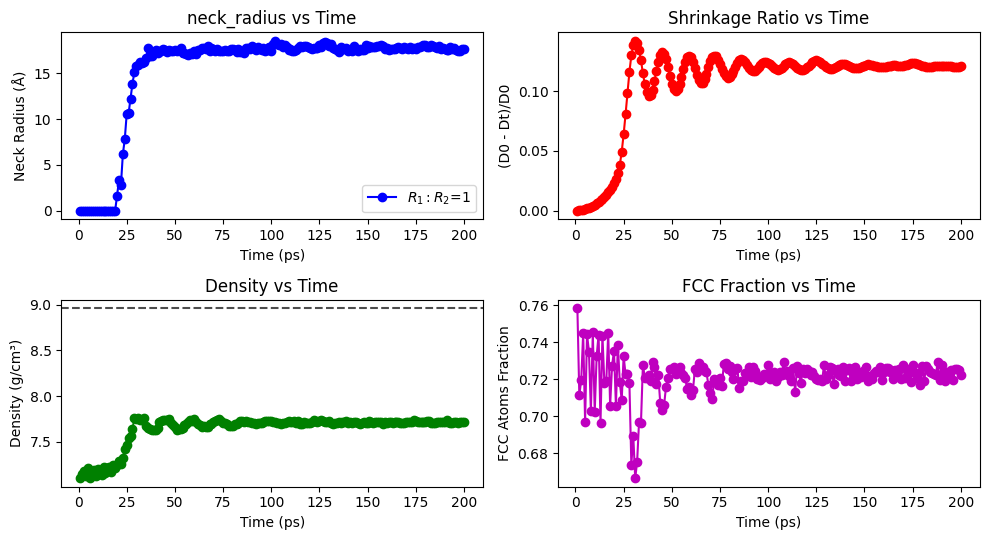

In [ ]:
if processed_files > 0:
    # Combine all trajectory DataFrames
    df_full = pd.concat(all_data, ignore_index=True)

    # Add derived features
    df_full['r_min'] = df_full[['r1', 'r2']].min(axis=1)
    df_full['r_max'] = df_full[['r1', 'r2']].max(axis=1)

    # Save dataset
    #df_full.to_parquet(IFP+OUTPUT_FILE)
    df_full.to_csv(IFP+OUTPUT_FILE.split('.')[0]+'_updated.csv')
    print(f"\nDataset saved to {OUTPUT_FILE}")
    print(f"Total simulations: {processed_files}")
    print(f"Total frames: {len(df_full)}")

    # Show dataset summary
    print("\nDataset Summary:")
    print(df_full.info())
    print("\nFirst 3 rows:")
    print(df_full.head(3))

    # Plot sample trajectory
    if 'sim_id' in df_full.columns:
        sample_sim = df_full['sim_id'].iloc[0]
        df_sample = df_full[df_full['sim_id'] == sample_sim].sort_values('time')

        fig, axs = plt.subplots(2, 2, figsize=(10, 5.5)) #fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(10, 5.5), sharex=True)

        # Neck growth
        axs[0, 0].plot(df_sample['time'], df_sample['neck_radius'], 'b-o', label=f'$R_1:R_2$=1')
        axs[0, 0].set_title('neck_radius vs Time')
        axs[0, 0].set_xlabel('Time (ps)')
        axs[0, 0].set_ylabel('Neck Radius (Å)')
        axs[0, 0].legend(loc='lower right')

        # Shrinkage
        axs[0, 1].plot(df_sample['time'], df_sample['shrinkage'], 'r-o')
        axs[0, 1].set_title('Shrinkage Ratio vs Time')
        axs[0, 1].set_xlabel('Time (ps)')
        axs[0, 1].set_ylabel('(D0 - Dt)/D0')

        # Density
        axs[1, 0].plot(df_sample['time'], df_sample['density'], 'g-o')
        axs[1, 0].axhline(y=BULK_DENSITY_CU, color='k', linestyle='--', alpha=0.7)
        axs[1, 0].set_title('Density vs Time')
        axs[1, 0].set_xlabel('Time (ps)')
        axs[1, 0].set_ylabel('Density (g/cm³)')

        # FCC Fraction
        axs[1, 1].plot(df_sample['time'], df_sample['fcc_fraction'], 'm-o')
        axs[1, 1].set_title('FCC Fraction vs Time')
        axs[1, 1].set_xlabel('Time (ps)')
        axs[1, 1].set_ylabel('FCC Atoms Fraction')

        plt.tight_layout()
        plt.savefig(IFP+'sample_trajectory_metrics.png')
        plt.show()

else:
    print("No valid trajectory files processed.")



# **Dataset Structure**
#
The final dataset contains:<p align=justify>
 - **Static features**: `sim_id`, `particle_type`, `r1`, `r2`, `size_ratio`, `T`
 - **Dynamic features**: `time`, `time_norm`, `Dt`, `potential_energy`, `gyration_radius`, `avg_coordination`
 - **Target variables**: `neck_radius`, `neck_ratio`, `shrinkage`, `density`, `fcc_fraction`
 - **Derived features**: `r_min`, `r_max`

 Format: Parquet (optimized for ML workflows)


In [ ]:
# Sample code to load the dataset for ML
try:
    df_loaded = pd.read_parquet(IFP+OUTPUT_FILE)
    print("\nDataset loaded successfully!")
    print(f"Shape: {df_loaded.shape}")
except:
    print("Error loading dataset")


Dataset loaded successfully!
Shape: (7200, 21)
